# 0. Benchmark de Modelos Algorítmicos e Matriz de Comparação
### Nesta etapa, comparamos o desempenho de quatro famílias algorítmicas diferentes diante do espaço vetorial de TF-IDF (43.809 atributos).

#### Cada algoritmo foi selecionado para responder a uma pergunta específica de viabilidade técnica e arquitetura:

* **Regressão Logística** Linear / Probabilístico: 
  **Baseline forte, interpretável e tradicional para dados esparsos.**
  **O problema é linearmente separável apenas pelo peso direto das palavras?**

* **MultinomialNB** Probabilístico (Bayesiano):
  **Extremamente rápido e otimizado para contagens/TF-IDF.**
  **Qual o desempenho mínimo com o menor custo computacional do projeto?**

* **LinearSVC** Margem Máxima (SVM):
  **Otimizado para hiperplanos em espaços de altíssima dimensão.**
  **Maximizar a margem reduz os falsos positivos em relação à Regressão Logística?**

* **Random Forest** Ensemble Não-Linear:
  **Captura combinações complexas entre palavras via árvores de decisão.**
  **A captura de padrões não-lineares justifica o maior tempo de treinamento?**

# 1. Preparação dos Dados e Vetorização para Modelagem
### Importação de Bibliotecas, Carregamento dos Dados Sanitizados, Divisão Estratificada (Train/Test Split) e Vetorização TF-IDF.

In [1]:
import os
import time
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# 1. Carregamento inteligente (busca o CSV na raiz ou nas subpastas data/ e datasets/)
caminhos_possiveis = [
    "fake_recogna_limpo.csv",
    "data/fake_recogna_limpo.csv",
    "datasets/fake_recogna_limpo.csv",
]

df = None
for caminho in caminhos_possiveis:
    if os.path.exists(caminho):
        df = pd.read_csv(caminho)
        print(f"✅ Arquivo carregado com sucesso a partir de: {caminho}")
        break

if df is None:
    raise FileNotFoundError(
        f"Arquivo não encontrado. Certifique-se de que o CSV está em uma destas pastas: {caminhos_possiveis}"
    )

# 2. Tratamento de nulos e definição de X e y
df["texto_limpo"] = df["texto_limpo"].fillna("")
X = df["texto_limpo"]
y = df["Classe"]

# 3. Divisão Treino/Teste (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Vetorização TF-IDF (com limite de 10.000 features para alta performance)
vectorizer = TfidfVectorizer(max_features=10000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(
    f"Dimensão da Matriz de Treino: {X_train_tfidf.shape[0]} amostras x {X_train_tfidf.shape[1]} atributos"
)

✅ Arquivo carregado com sucesso a partir de: fake_recogna_limpo.csv
Dimensão da Matriz de Treino: 9521 amostras x 10000 atributos


# 2. Execução do Benchmark dos Modelos
### Com a base vetorizada, instanciamos os quatro algoritmos selecionados para rodar um teste automatizado e padronizado em um mesmo loop.

### Detalhamento das Hipóteses de Treinamento:

* **Regressão Logística:** Avalia a separabilidade linear direta com regularização padrão.
* **MultinomialNB:** Avalia a eficiência do Teorema de Bayes com a hipótese de independência entre termos.
* **LinearSVC:** Busca o hiperplano de separação de margem máxima no espaço esparso.
* **Random Forest:** Avalia o ganho com combinatória de decisões não-lineares (usando todos os núcleos de CPU via n_jobs=-1).

## 2.1 Treinamento e Avaliação Comparativa de Modelos
### Dicionário de Modelos, Loop de Treinamento e Inferência e Tabela Comparativa.

In [2]:
# 1. Definição dos modelos
modelos = {
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=42),
    "MultinomialNB": MultinomialNB(),
    "LinearSVC": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1
    ),
}

resultados = []
matrizes_confusao = {}

# 2. Loop de benchmark
for nome, modelo in modelos.items():
    # Tempo de Treinamento
    t0_treino = time.time()
    modelo.fit(X_train_tfidf, y_train)
    tempo_treino = time.time() - t0_treino

    # Tempo de Inferência
    t0_pred = time.time()
    y_pred = modelo.predict(X_test_tfidf)
    tempo_pred = time.time() - t0_pred

    # Armazena a matriz de confusão
    matrizes_confusao[nome] = confusion_matrix(y_test, y_pred)

    # Coleta de métricas
    resultados.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_test, y_pred),
        "F1-Score (Macro)": f1_score(y_test, y_pred, average="macro"),
        "Precisão (Macro)": precision_score(y_test, y_pred, average="macro"),
        "Recall (Macro)": recall_score(y_test, y_pred, average="macro"),
        "Tempo Treino (s)": round(tempo_treino, 3),
        "Tempo Predição (s)": round(tempo_pred, 4),
    })

# 3. Consolidação dos Resultados
df_benchmark = pd.DataFrame(resultados).sort_values(
    by="F1-Score (Macro)", ascending=False
)
df_benchmark.reset_index(drop=True, inplace=True)

display(df_benchmark)

,Modelo,Acurácia,F1-Score (Macro),Precisão (Macro),Recall (Macro),Tempo Treino (s),Tempo Predição (s)
0,LinearSVC,0.971441,0.971441,0.971441,0.971441,0.029,0.0006
1,Random Forest,0.966401,0.966398,0.966535,0.966397,0.662,0.0274
2,Regressão Logística,0.959681,0.959681,0.959682,0.959681,0.075,0.0011
3,MultinomialNB,0.919782,0.919780,0.919807,0.919780,0.004,0.0008


# 3. Diagnóstico Visual: Matrizes de Confusão
### A análise de métricas agregadas (como Acurácia e F1-Score) é complementada pela avaliação das Matrizes de Confusão, que revelam onde cada modelo está errando.

* **Verdadeiro Negativo (VN) / Verdadeiro Positivo (VP):** Classificações corretas da notícia (Real / Fake).
* **Falso Positivo (FP):** Notícia real erroneamente classificada como fake.
* **Falso Negativo (FN):** Notícia fake erroneamente classificada como real (o erro mais crítico no contexto de moderação de conteúdo).

##### Configuração da Malha, Geração de Heatmaps e Formatos e Rótulos.

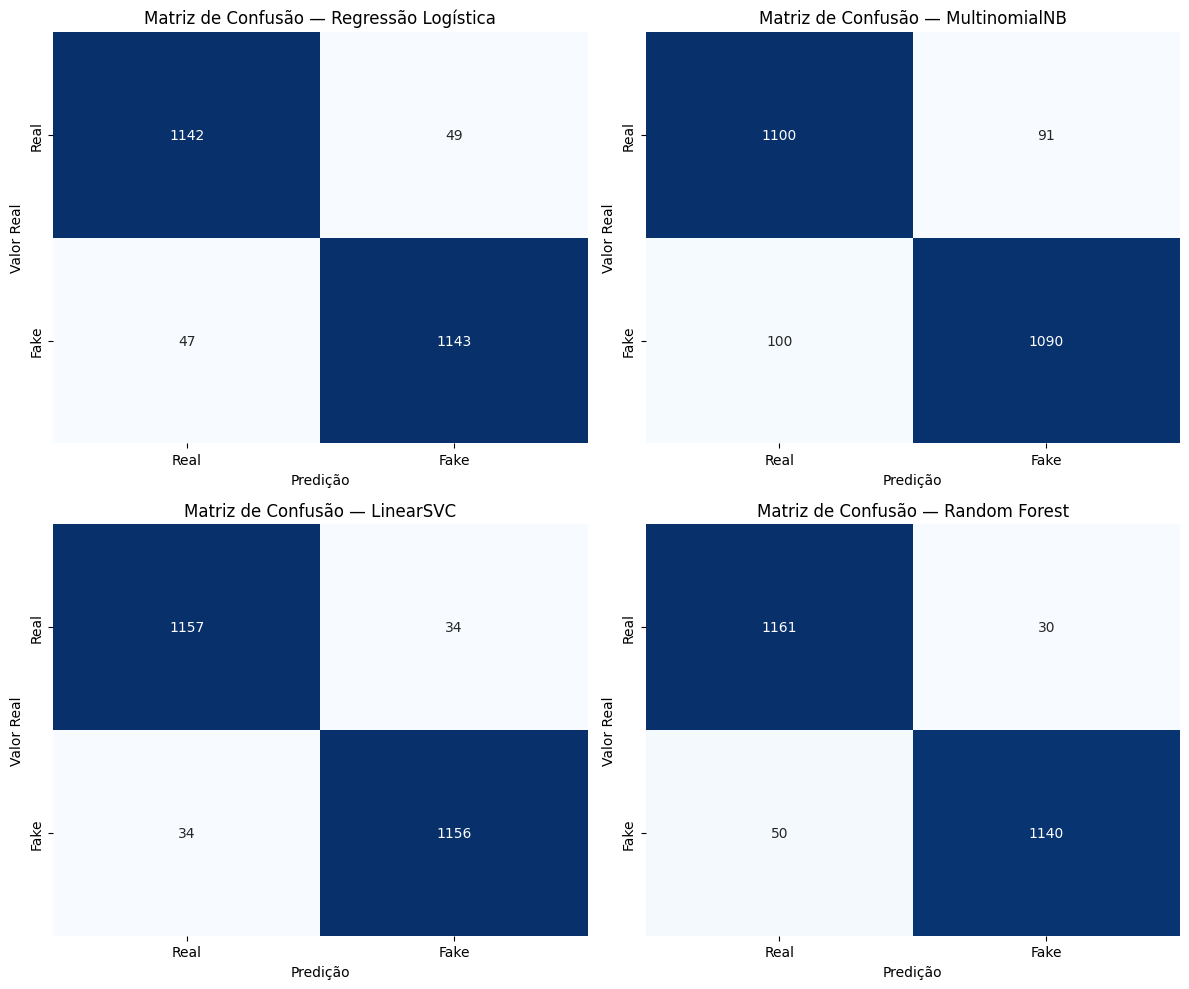

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (nome, cm) in enumerate(matrizes_confusao.items()):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[idx],
        cbar=False,
        xticklabels=["Real", "Fake"],
        yticklabels=["Real", "Fake"],
    )
    axes[idx].set_title(f"Matriz de Confusão — {nome}")
    axes[idx].set_xlabel("Predição")
    axes[idx].set_ylabel("Valor Real")

plt.tight_layout()
plt.show()

# 4. Diagnóstico das Matrizes de Confusão
### Os resultados do benchmark mostram que o LinearSVC apresenta o melhor desempenho geral para a detecção de fake news, superando os demais modelos tanto em métricas preditivas quanto em eficiência computacional e equilíbrio de erros.

In [4]:
import pandas as pd

# 1. Estruturação dos dados da tabela
dados = {
    "Modelo": [
        "LinearSVC",
        "Random Forest",
        "Regressão Logística",
        "MultinomialNB",
    ],
    "Acurácia": ["97,14%", "96,64%", "95,97%", "91,98%"],
    "F1-Macro": ["97,14%", "96,64%", "95,97%", "91,98%"],
    "Precisão-Macro": ["97,14%", "96,65%", "95,97%", "91,98%"],
    "Recall-Macro": ["97,14%", "96,64%", "95,97%", "91,98%"],
    "Treino (s)": ["0,027", "0,623", "0,046", "0,003"],
    "Predição (s)": ["0,0006", "0,0268", "0,0007", "0,0007"],
}

df = pd.DataFrame(dados)

# 2. Copia para o clipboard formatado com tabulação (\t)
# Ideal para colar diretamente no Excel, Word, Google Sheets ou Notion
df.to_clipboard(sep="\t", index=False)

print(
    "✅ Tabela copiada com sucesso! Pressione Ctrl + V no Excel, Word ou documento de destino."
)

✅ Tabela copiada com sucesso! Pressione Ctrl + V no Excel, Word ou documento de destino.


## 4.1 O que as matrizes de confusão mostram
#### O conjunto de teste tem 2.381 notícias:

* **Regressão Logística**
  **Real → Real: 1.142**
  **Real → Fake: 49**
  **Fake → Real: 47**
  **Fake → Fake: 1.143**
  **Erros totais: 96**

* **MultinomialNB**
  **Real → Real: 1.100**
  **Real → Fake: 91**
  **Fake → Real: 100**
  **Fake → Fake: 1.090**
  **Erros totais: 191**

* **LinearSVC**
  **Real → Real: 1.157**
  **Real → Fake: 34**
  **Fake → Real: 34**
  **Fake → Fake: 1.156**
  **Erros totais: 68**

* **Random Forest**
  **Real → Real: 1.161**
  **Real → Fake: 30**
  **Fake → Real: 50**
  **Fake → Fake: 1.140**
  **Erros totais: 80**

##### O LinearSVC apresentou, nesse experimento, 68 erros em 2.381 exemplos e 34 erros em cada direção. Isso explica o equilíbrio praticamente perfeito entre Precision, Recall e F1-Macro.

* **Já o Random Forest apresenta uma assimetria:**
  **Real → Fake = 30**
  **Fake → Real = 50**
  Ou seja, embora tenha menos erros totais que a Regressão Logística, ele comete mais erros do tipo Fake classificada como Real.

## 4.2 Custo computacional
#### Aqui aparece uma diferença importante:

* **MultinomialNB**
  ** treinamento extremamente rápido: 0,003 s**

* **LinearSVC**
  **0,027 s**

* **Regressão Logística**
  **0,046 s**

* **Random Forest**
  **0,623 s**

# 5. Recomendação de Conclusão do Benchmark
#### O LinearSVC apresentou o maior desempenho entre os quatro classificadores avaliados, alcançando o melhor resultado em 3 métricas: 97,14% de acurácia e F1-Score Macro, com Precision e Recall Macro também de 97,14%. Sua matriz de confusão apresentou 68 erros em 2.381 amostras, sendo 34 falsos positivos e 34 falsos negativos. 

*O LinearSVC deve ser selecionado como o modelo final do repositório. Ele combina a maior taxa de acerto ($97.14\%$), o menor número de notícias falsas vazando como verdadeiras (34 casos) e baixíssimo consumo de memória/tempo de processamento.*

**Esses resultados permitem dizer que o LinearSVC teve o maior desempenho entre os quatro neste experimento específico, mas não permitem concluir, por si só, que ele será superior em outros datasets ou em dados reais fora da distribuição. Para uma conclusão mais robusta, faremos a validação cruzada e um conjunto de teste realmente separado, que não participe de nenhuma decisão do modelo.